# Lab Task 1 – Reinforcement Learning Laboratory
## Experiment 1: Exploring Reinforcement Learning Environments using Gymnasium

**Course Outcome:** CO1  


This notebook covers:
1. Environment Setup
2. Creating and Initializing an RL Environment
3. Exploring Observation and Action Spaces
4. Executing a Random Agent


## Task 1: Environment Setup

- Install Gymnasium, NumPy, and Matplotlib
- Import the required libraries
- Verify the installation by printing the Gymnasium version

In [1]:
# Install required libraries (run once)
!pip install gymnasium numpy matplotlib -q

In [2]:
# Import required libraries
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Verify installation by printing the Gymnasium version
print("Gymnasium version:", gym.__version__)

Gymnasium version: 1.3.0


## Task 2: Create and Initialize an RL Environment

- Create the `CartPole-v1` environment
- Reset the environment
- Display the initial observation and environment information

In [3]:
# Create the CartPole-v1 environment
env = gym.make("CartPole-v1")

# Reset the environment (seed for reproducibility)
initial_observation, info = env.reset(seed=42)

print("Initial Observation:", initial_observation)
print("Additional Info:", info)

Initial Observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Additional Info: {}


## Task 3: Explore Observation and Action Spaces

- Display the observation space
- Display the action space
- Display the type of observation space
- Display the number of possible actions

In [4]:
# Display the observation space
print("Observation Space:", env.observation_space)

# Display the action space
print("Action Space:", env.action_space)

# Display the type of observation space
print("Type of Observation Space:", type(env.observation_space))

# Display the number of possible actions
print("Number of possible actions:", env.action_space.n)

Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action Space: Discrete(2)
Type of Observation Space: <class 'gymnasium.spaces.box.Box'>
Number of possible actions: 2


**Interpretation:**
- The observation space is a `Box` of shape `(4,)` representing: cart position, cart velocity, pole angle, and pole angular velocity.
- The action space is `Discrete(2)`: `0` = push cart left, `1` = push cart right.

## Task 4: Execute a Random Agent

- Execute a random action at every time step
- Run the environment for one complete episode
- Print step number, selected action, observation, reward, and episode status
- Display the total number of steps and cumulative reward

In [5]:
# Reset environment before running the episode
observation, info = env.reset(seed=42)

total_reward = 0
step_count = 0
terminated = False
truncated = False

print(f"{'Step':<6}{'Action':<8}{'Observation':<45}{'Reward':<8}{'Terminated':<12}{'Truncated':<10}")
print("-" * 90)

while not (terminated or truncated):
    # Execute a random action at every time step
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)

    total_reward += reward
    step_count += 1

    print(f"{step_count:<6}{action:<8}{str(np.round(observation, 4)):<45}{reward:<8}{str(terminated):<12}{str(truncated):<10}")

print("-" * 90)
print(f"Total number of steps: {step_count}")
print(f"Cumulative reward: {total_reward}")

env.close()

Step  Action  Observation                                  Reward  Terminated  Truncated 
------------------------------------------------------------------------------------------
1     1       [ 0.0273  0.1885  0.0363 -0.2614]            1.0     False       False     
2     0       [ 0.031  -0.0071  0.031   0.0425]            1.0     False       False     
3     0       [ 0.0309 -0.2027  0.0319  0.3448]            1.0     False       False     
4     1       [ 0.0268 -0.008   0.0388  0.0623]            1.0     False       False     
5     0       [ 0.0267 -0.2037  0.04    0.367 ]            1.0     False       False     
6     1       [ 0.0226 -0.0092  0.0474  0.0872]            1.0     False       False     
7     0       [ 0.0224 -0.2049  0.0491  0.3944]            1.0     False       False     
8     0       [ 0.0183 -0.4007  0.057   0.7022]            1.0     False       False     
9     1       [ 0.0103 -0.2064  0.071   0.428 ]            1.0     False       False     
10    1  

### Optional: Visualize reward accumulation over the episode
A quick plot showing the cumulative reward growing step by step (since CartPole gives +1 reward per surviving step).

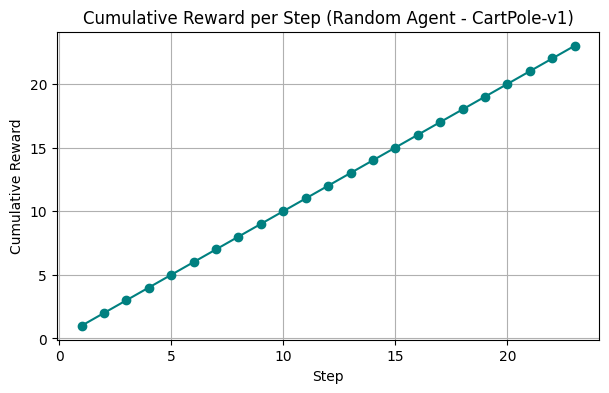

In [6]:
# Re-run an episode while logging rewards for plotting
env = gym.make("CartPole-v1")
observation, info = env.reset(seed=42)

rewards = []
terminated = truncated = False
cumulative = 0

while not (terminated or truncated):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    cumulative += reward
    rewards.append(cumulative)

env.close()

plt.figure(figsize=(7,4))
plt.plot(range(1, len(rewards)+1), rewards, marker='o', color='teal')
plt.title("Cumulative Reward per Step (Random Agent - CartPole-v1)")
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.grid(True)
plt.show()